Import Library

In [2]:
import numpy as np
import json
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tensorflow.keras.models    import Sequential, Model
from tensorflow.keras.layers    import (Conv1D, AveragePooling1D,
                                        Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os
import seaborn as sns

Konfigurasi

In [3]:
X_train_raw = np.load("X_train_raw.npy")
y_train     = np.load("y_train.npy")
X_val_raw   = np.load("X_val_raw.npy")
y_val       = np.load("y_val.npy")
X_test_raw  = np.load("X_test_raw.npy")
y_test      = np.load("y_test.npy")

with open("config.json", "r") as f:
    config = json.load(f)
TARGET_CRYSTAL_SYS = config["TARGET_CRYSTAL_SYS"]
CRYSTAL_SYS_MAP    = {int(k): v for k, v in config["CRYSTAL_SYS_MAP"].items()}
N_POINTS           = config["N_POINTS"]
EPOCHS             = config["EPOCHS"]
BATCH_SIZE         = config["BATCH_SIZE"]

Fungsi Label Encoding

In [4]:
le = LabelEncoder()
le.classes_ = np.array(sorted(TARGET_CRYSTAL_SYS))
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
y_val_enc   = le.transform(y_val)

CLASS_NAMES = [CRYSTAL_SYS_MAP[c] for c in le.classes_]
N_CLASSES = len(CLASS_NAMES)

y_train_cat = to_categorical(y_train_enc, N_CLASSES)
y_test_cat  = to_categorical(y_test_enc, N_CLASSES)
y_val_cat   = to_categorical(y_val_enc, N_CLASSES)

X_train_cnn = X_train_raw[..., np.newaxis]
X_test_cnn  = X_test_raw[..., np.newaxis]
X_val_cnn   = X_val_raw[..., np.newaxis]

Fungsi Arsitektur CNN

In [5]:
def build_cnn(input_length, n_classes):
    import tensorflow as tf
    inputs = tf.keras.Input(shape=(input_length, 1), name="input_xrd")

    # Layer 1 
    x = Conv1D(filters=80, kernel_size=35, activation="relu", padding="same", strides=5)(inputs)
    x = AveragePooling1D(pool_size=3, strides=2)(x)
    x = Dropout(0.3)(x)

    # Layer 2 
    x = Conv1D(filters=80, kernel_size=3, activation="relu", padding="same", strides=5)(x)
    x = AveragePooling1D(pool_size=3, strides=2)(x)
    x = Dropout(0.3)(x)

    # Layer 3 
    x = Conv1D(filters=80, kernel_size=3, activation="relu", padding="same", strides=2)(x)
    x = AveragePooling1D(pool_size=3, strides=1)(x)
    x = Dropout(0.3)(x)

    x = AveragePooling1D(pool_size=3, strides=1)(x)
    x = Flatten(name="flatten_features")(x)

    # Fully Connected Layer 1
    x = Dense(64, activation="relu", name="fc1")(x)
    x = Dropout(0.5, name="dropout_fc1")(x)

    # Fully Connected Layer 2
    x = Dense(16, activation="relu", name="fc2_before_softmax")(x)
    x = Dropout(0.5, name="dropout_fc2")(x)

    outputs = Dense(n_classes, activation="softmax", name="softmax_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Perovskite_XRD_CNN")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=1),
    ]

Training Model

In [6]:
X_train_cnn = X_train_raw[..., np.newaxis]
X_test_cnn  = X_test_raw[...,  np.newaxis]
X_val_cnn   = X_val_raw[...,   np.newaxis]
print(f"   Train : {X_train_cnn.shape}")
print(f"   Val   : {X_val_cnn.shape}   <- monitor saja")
print(f"   Test  : {X_test_cnn.shape}  <- evaluasi akhir\n")

model   = build_cnn(N_POINTS, N_CLASSES)
model.summary()

history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val_cnn, y_val_cat),
    callbacks=get_callbacks(), verbose=1
)

   Train : (8232, 4500, 1)
   Val   : (1029, 4500, 1)   <- monitor saja
   Test  : (1029, 4500, 1)  <- evaluasi akhir



Model: "Perovskite_XRD_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xrd (InputLayer)          │ (None, 4500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 900, 80)        │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 449, 80)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 449, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 80)         │        19,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 44, 80)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 80)         │        19,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 20, 80)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 18, 80)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_features (Flatten)      │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_fc1 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2_before_softmax (Dense)      │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_fc2 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,772 (526.45 KB)

 Trainable params: 134,772 (526.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.5420 - loss: 1.2154 - val_accuracy: 0.5948 - val_loss: 1.0954
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5831 - loss: 1.1275 - val_accuracy: 0.5948 - val_loss: 1.0001
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5869 - loss: 1.0468 - val_accuracy: 0.6210 - val_loss: 0.8828
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6216 - loss: 0.9817 - val_accuracy: 0.6482 - val_loss: 0.8699
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6337 - loss: 0.9365 - val_accuracy: 0.6900 - val_loss: 0.7756
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6466 - loss: 0.9008 - val_accuracy: 0.6948 - val_loss: 0.7513
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6580 - loss: 0.8827 - val_accuracy: 0.6822 - val_loss: 0.7837
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6732 - loss: 0.8330 - val_accuracy: 0.

Grafik Riwayat Training Model

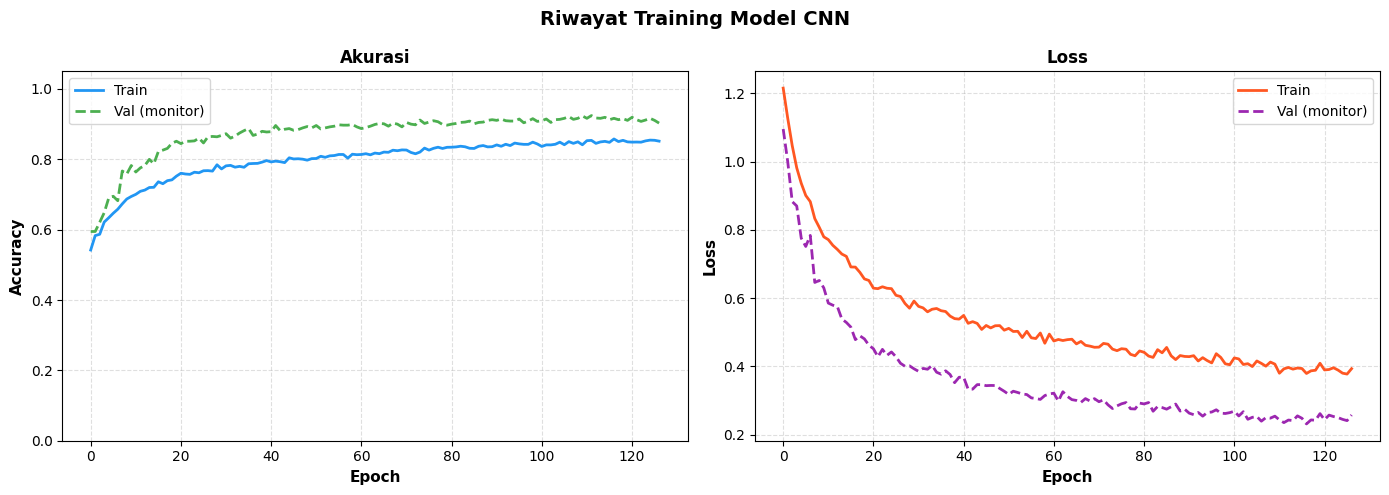

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Riwayat Training Model CNN",
             fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],
             color="#2196F3", linewidth=2, label="Train")
axes[0].plot(history.history["val_accuracy"],
             color="#4CAF50", linewidth=2, linestyle="--", label="Val (monitor)")
axes[0].set_title("Akurasi", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Epoch", fontweight="bold", fontsize=11)
axes[0].set_ylabel("Accuracy", fontweight="bold", fontsize=11)
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)
axes[0].set_ylim(0, 1.05)

axes[1].plot(history.history["loss"],
             color="#FF5722", linewidth=2, label="Train")
axes[1].plot(history.history["val_loss"],
             color="#9C27B0", linewidth=2, linestyle="--", label="Val (monitor)")
axes[1].set_title("Loss", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Epoch", fontweight="bold", fontsize=11)
axes[1].set_ylabel("Loss", fontweight="bold", fontsize=11)
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Evaluasi Metrik dari Model CNN

In [8]:
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     accuracy_score, precision_score,
                                     recall_score, f1_score)

eval_models = [("CNN", model)]

models_results = {}
for model_name, mdl in eval_models:
    y_pred_tmp = np.argmax(mdl.predict(X_test_cnn, verbose=0), axis=1)
    models_results[model_name] = {
        "accuracy"          : accuracy_score(y_test_enc, y_pred_tmp),
        "macro_precision"   : precision_score(y_test_enc, y_pred_tmp, average="macro",    zero_division=0),
        "macro_recall"      : recall_score(y_test_enc, y_pred_tmp,    average="macro",    zero_division=0),
        "macro_f1"          : f1_score(y_test_enc, y_pred_tmp,        average="macro",    zero_division=0),
        "predictions"       : y_pred_tmp,
        "report"            : classification_report(
                                  y_test_enc, y_pred_tmp,
                                  target_names=CLASS_NAMES,
                                  digits=4,
                                  output_dict=True
                              )
    }

for model_name, res in models_results.items():
    print(f"\n{'='*65}")
    print(f"  EVALUASI TEST SET - {model_name}")
    print(f"{'='*65}")
    print(f"\n  {'Kelas':<15} {'Precision':>10} {'Recall':>10} "
          f"{'F1-Score':>10} {'Support':>9}")
    print(f"  {'-'*54}")
    for cls in CLASS_NAMES:
        p  = res["report"][cls]["precision"]
        r  = res["report"][cls]["recall"]
        f1 = res["report"][cls]["f1-score"]
        s  = int(res["report"][cls]["support"])
        print(f"  {cls:<15} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {s:>9}")
    print(f"  {'-'*54}")
    print(f"\n  {'Metrik':<25} {'Macro':>10}")
    print(f"  {'-'*45}")
    print(f"  {'Accuracy':<25} {res['accuracy']:>10.4f}")
    print(f"  {'Precision':<25} {res['macro_precision']:>10.4f}")
    print(f"  {'Recall':<25} {res['macro_recall']:>10.4f} ")
    print(f"  {'F1-Score':<25} {res['macro_f1']:>10.4f} ")
    print(f"  {'='*45}")

loss_val, _ = model.evaluate(X_test_cnn, y_test_cat, verbose=0)
acc_val     = models_results["CNN"]["accuracy"]
y_pred      = models_results["CNN"]["predictions"]
report_val  = models_results["CNN"]["report"]




  EVALUASI TEST SET - CNN

  Kelas            Precision     Recall   F1-Score   Support
  ------------------------------------------------------
  Kubik               0.8349     0.9479     0.8878       192
  Tetragonal          1.0000     0.5088     0.6744        57
  Ortorombik          0.9274     0.9608     0.9438       612
  Monoklinik          0.9459     0.8333     0.8861       168
  ------------------------------------------------------

  Metrik                         Macro
  ---------------------------------------------
  Accuracy                      0.9125
  Precision                     0.9271
  Recall                        0.8127 
  F1-Score                      0.8480 


Confusion Matrix

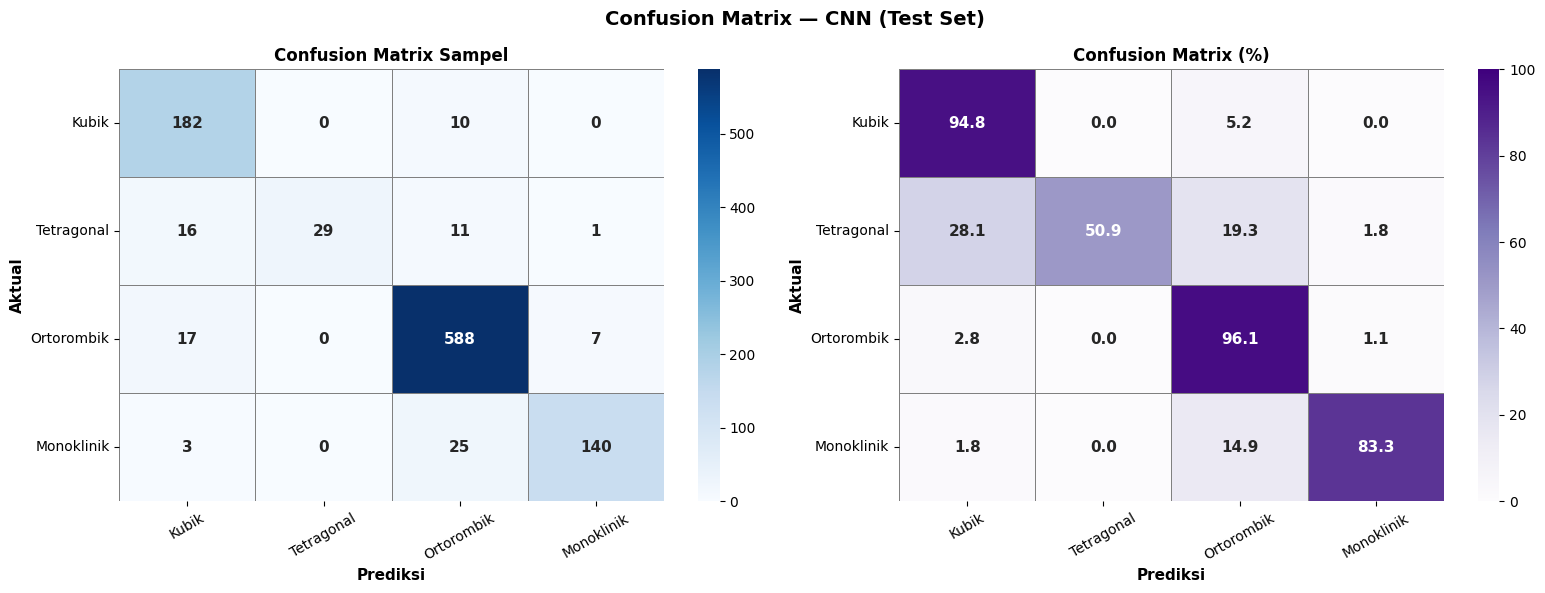

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — CNN (Test Set)",
             fontsize=14, fontweight="bold")

for (title, cmap, ax, fmt) in [
    ("Sampel", "Blues",   axes[0], "d"),
    ("(%)",   "Purples", axes[1], ".1f"),
]:
    cm = confusion_matrix(y_test_enc, y_pred)
    if "%" in title:
        cm   = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        vmax = 100
    else:
        vmax = cm.max()
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor="gray",
                annot_kws={"size": 11, "weight": "bold"},
                vmin=0, vmax=vmax)
    ax.set_title(f"Confusion Matrix {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Prediksi", fontweight="bold", fontsize=11)
    ax.set_ylabel("Aktual", fontweight="bold", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


Menyimpan Model CNN

In [10]:
model.save("model_CNN2.h5")